## Notebook for analysing the results of hallucination probes

In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

api = wandb.Api()
project = api.project("hallucination-probes")

In [2]:
# check for run by id

apertus_run = api.run("ethz-lsai-25/hallucination-probes/ynankpjz") # apertus no lora
llama_run = api.run("ethz-lsai-25/hallucination-probes/rct5pows")

print(apertus_run.summary)

{'_runtime': 3729.216289863, '_step': 2476, '_timestamp': 1771171766.0704973, '_wandb': {'runtime': 3729}, 'total_flos': 0, 'train/active_positions': 1177, 'train/epoch': 1, 'train/global_step': 2249, 'train/grad_norm': 668, 'train/kl_loss': 0, 'train/lambda_kl': 0.5, 'train/lambda_lm': 0, 'train/learning_rate': 4.446420631391729e-06, 'train/lm_loss': 0.23582424223423004, 'train/longfact_test_apertus/all_accuracy': 0.9463662151838992, 'train/longfact_test_apertus/all_auc': 0.6544677038267276, 'train/longfact_test_apertus/all_f1': 0.2835570288041771, 'train/longfact_test_apertus/all_optimal_threshold': 1, 'train/longfact_test_apertus/all_precision': 0.26685152713778904, 'train/longfact_test_apertus/all_pred_negative_count': 1184076, 'train/longfact_test_apertus/all_pred_positive_count': 49046, 'train/longfact_test_apertus/all_recall': 0.3024938174590334, 'train/longfact_test_apertus/all_recall_at_0.1_fpr': 0.34760903228788687, 'train/longfact_test_apertus/all_threshold_optimized_accurac

In [3]:

def summary_df(run):
    cfg = {k: v for k, v in run.summary._json_dict.items() if not k.startswith("_")}
    return pd.DataFrame.from_dict(cfg, orient="index", columns=["value"])

apertus_summary_df = summary_df(apertus_run)
llama_summary_df   = summary_df(llama_run)

apertus_summary_df = pd.DataFrame.from_dict(apertus_run.summary._json_dict, orient="index", columns=["value"])  # [web:17]
llama_summary_df   = pd.DataFrame.from_dict(llama_run.summary._json_dict, orient="index", columns=["value"])    # [web:17]


In [4]:
summary_side_by_side = pd.DataFrame({
    "apertus": apertus_summary_df["value"],
    "llama":   llama_summary_df["value"],
})

In [5]:
summary_side_by_side["apertus"].index

Index(['_runtime', '_step', '_timestamp', '_wandb', 'total_flos',
       'train/active_positions', 'train/epoch', 'train/global_step',
       'train/grad_norm', 'train/kl_loss',
       ...
       'train/longfact_test_llama/span_true_negative_count',
       'train/longfact_test_llama/span_true_positive_count',
       'train/longfact_test_llama/sparsity', 'train/loss',
       'train/max_aggr_probe_loss', 'train/omega', 'train_loss',
       'train_runtime', 'train_samples_per_second', 'train_steps_per_second'],
      dtype='object', length=107)

In [6]:
summary_side_by_side["apertus"]["train/longfact_test_apertus/all_auc"]

0.6544677038267276

### plot AUC and F1 of the runs

In [7]:
import numpy as np


metric = "F1"
metric_name = "all_" + metric.lower()

# [[Train Apertus/Test Apertus, Train Apertus/Test Llama],
#  [Train Llama/Test Apertus,   Train Llama/Test Llama]]

model_names = ["apertus", "llama"]

data = np.array(
    [
        [summary_side_by_side[model][f"train/longfact_test_{ref_model}/{metric_name}"] for model in model_names] for ref_model in model_names
    ]
)

reference = np.array(
    [
        ["test: " + ref_model + ", train: " + model for model in model_names] for ref_model in model_names
    ]
)

reference

array([['test: apertus, train: apertus', 'test: apertus, train: llama'],
       ['test: llama, train: apertus', 'test: llama, train: llama']],
      dtype='<U29')

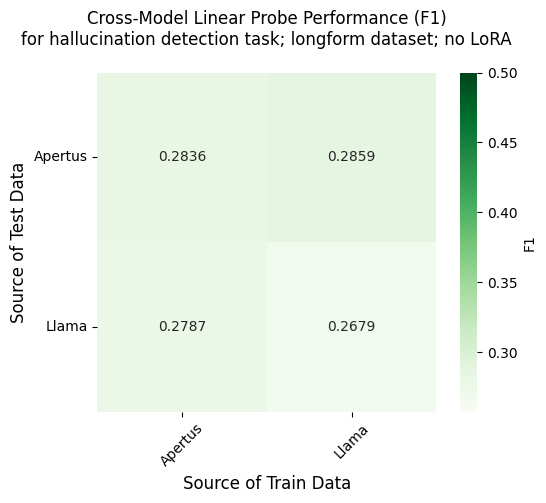

In [8]:


# Define labels
y_labels = ["Apertus", "Llama"] # Test Data Sources
x_labels = ["Apertus", "Llama"] # Train Data Sources

# 2. Setup the plot
plt.figure(figsize=(6, 5))


ax = sns.heatmap(data, annot=True, fmt=".4f", cmap="Greens", vmin=0.5,
                 xticklabels=x_labels, yticklabels=y_labels,
                 cbar_kws={'label': metric}, square=True)

# 3. Add Labels, Title, and Formatting
plt.title(f"Cross-Model Linear Probe Performance ({metric})\nfor hallucination detection task; longform dataset; no LoRA", fontsize=12, pad=20)
plt.xlabel("Source of Train Data", fontsize=12)
plt.ylabel("Source of Test Data", fontsize=12)

# Rotate x-axis labels to match the reference style (45 degrees)
plt.xticks(rotation=45)
plt.yticks(rotation=0) # Keep y-axis horizontal

plt.tight_layout()

plt.show()

lora kl=0.5

In [9]:
# check for run by id

apertus_run_lora = api.run("ethz-lsai-25/hallucination-probes/payanx0q") # apertus no lora
llama_run_lora = api.run("ethz-lsai-25/hallucination-probes/fsr8yp0j")

print(apertus_run_lora.summary)

def summary_df(run):
    cfg = {k: v for k, v in run.summary._json_dict.items() if not k.startswith("_")}
    return pd.DataFrame.from_dict(cfg, orient="index", columns=["value"])

apertus_summary_df_lora = summary_df(apertus_run_lora)
llama_summary_df_lora   = summary_df(llama_run_lora)

apertus_summary_df = pd.DataFrame.from_dict(apertus_run.summary._json_dict, orient="index", columns=["value"])  # [web:17]
llama_summary_df   = pd.DataFrame.from_dict(llama_run.summary._json_dict, orient="index", columns=["value"])    # [web:17]

summary_side_by_side_lora = pd.DataFrame({
    "apertus": apertus_summary_df_lora["value"],
    "llama":   llama_summary_df_lora["value"],
})

{'_runtime': 11503.803897142, '_step': 2476, '_timestamp': 1771179540.657334, '_wandb': {'runtime': 11503}, 'total_flos': 0, 'train/active_positions': 1177, 'train/epoch': 1, 'train/global_step': 2249, 'train/grad_norm': 0.0013723807642236352, 'train/kl_loss': 0.001157024409621954, 'train/lambda_kl': 0.5, 'train/lambda_lm': 0, 'train/learning_rate': 4.446420631391729e-06, 'train/lm_loss': 0.2357257604598999, 'train/longfact_test_apertus/all_accuracy': 0.9649126363814772, 'train/longfact_test_apertus/all_auc': 0.5, 'train/longfact_test_apertus/all_f1': 0, 'train/longfact_test_apertus/all_optimal_threshold': 0, 'train/longfact_test_apertus/all_precision': 0, 'train/longfact_test_apertus/all_pred_negative_count': 1233122, 'train/longfact_test_apertus/all_pred_positive_count': 0, 'train/longfact_test_apertus/all_recall': 0, 'train/longfact_test_apertus/all_recall_at_0.1_fpr': 0, 'train/longfact_test_apertus/all_threshold_optimized_accuracy': 0.03508736361852274, 'train/longfact_test_apertu

In [10]:
import numpy as np


metric = "F1"
metric_name = "all_" + metric.lower()

# [[Train Apertus/Test Apertus, Train Apertus/Test Llama],
#  [Train Llama/Test Apertus,   Train Llama/Test Llama]]

model_names = ["apertus", "llama"]

data_lora = np.array(
    [
        [summary_side_by_side_lora[model][f"train/longfact_test_{ref_model}/{metric_name}"] for model in model_names] for ref_model in model_names
    ]
)

reference = np.array(
    [
        ["test: " + ref_model + ", train: " + model for model in model_names] for ref_model in model_names
    ]
)

reference

array([['test: apertus, train: apertus', 'test: apertus, train: llama'],
       ['test: llama, train: apertus', 'test: llama, train: llama']],
      dtype='<U29')

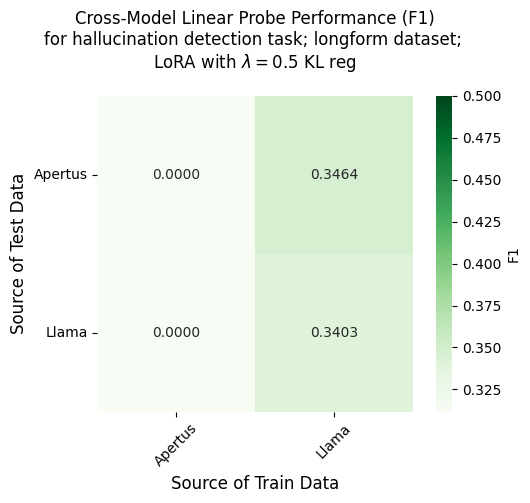

In [11]:


# Define labels
y_labels = ["Apertus", "Llama"] # Test Data Sources
x_labels = ["Apertus", "Llama"] # Train Data Sources

# 2. Setup the plot
plt.figure(figsize=(6, 5))


ax = sns.heatmap(data_lora, annot=True, fmt=".4f", cmap="Greens", vmin=0.5,
                 xticklabels=x_labels, yticklabels=y_labels,
                 cbar_kws={'label': metric}, square=True)

# 3. Add Labels, Title, and Formatting
plt.title(f"Cross-Model Linear Probe Performance ({metric})\nfor hallucination detection task; longform dataset; \nLoRA with $\\lambda=0.5$ KL reg", fontsize=12, pad=20)

plt.xlabel("Source of Train Data", fontsize=12)
plt.ylabel("Source of Test Data", fontsize=12)

# Rotate x-axis labels to match the reference style (45 degrees)
plt.xticks(rotation=45)
plt.yticks(rotation=0) # Keep y-axis horizontal

plt.tight_layout()

plt.show()

inspect loss curves now, probe trained on apertus seems really weird

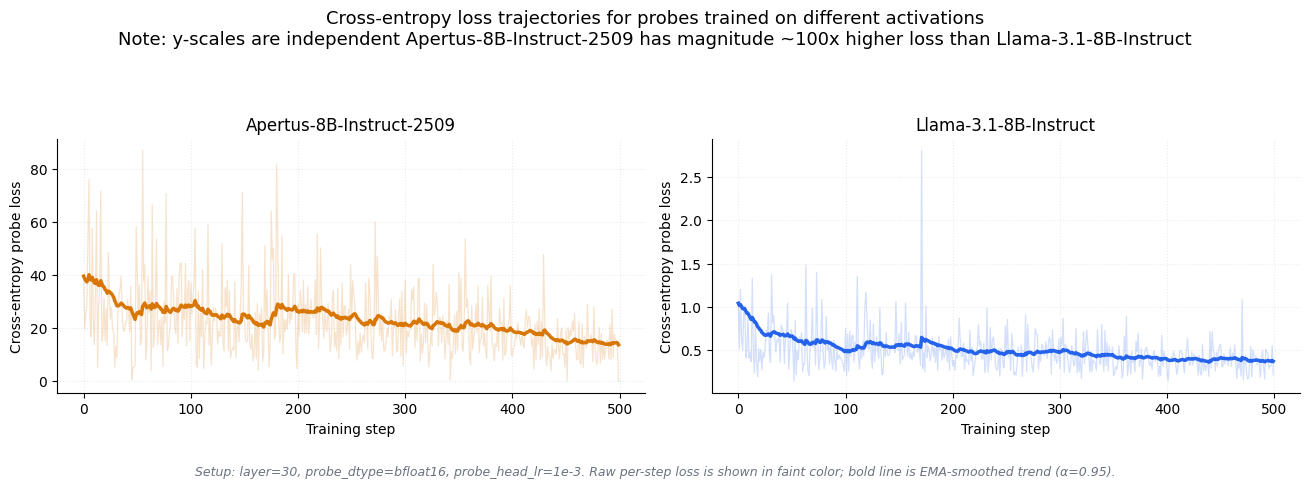

In [15]:
# No-LoRA loss comparison with consistent visual semantics
apertus_history = apertus_run.history(keys=["train/loss"])
llama_history = llama_run.history(keys=["train/loss"])

MODEL_DISPLAY = {
    "apertus": "Apertus-8B-Instruct-2509",
    "llama": "Llama-3.1-8B-Instruct",
}
COLOR_BY_MODEL = {
    "apertus": "#D97706",  # orange
    "llama": "#2563EB",    # blue
}

def ema_smooth(values, alpha=0.95):
    if len(values) == 0:
        return values
    smoothed = []
    last = values[0]
    for v in values:
        last = alpha * last + (1 - alpha) * v
        smoothed.append(last)
    return smoothed

def _loss_values(hist_df):
    if "train/loss" not in hist_df.columns:
        return []
    return hist_df["train/loss"].dropna().tolist()

ap_raw = _loss_values(apertus_history)
ll_raw = _loss_values(llama_history)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), sharex=False, sharey=False)

for ax, model_key, raw in [
    (axes[0], "apertus", ap_raw),
    (axes[1], "llama", ll_raw),
]:
    color = COLOR_BY_MODEL[model_key]
    title = MODEL_DISPLAY[model_key]

    if len(raw) == 0:
        ax.text(0.5, 0.5, "No train/loss history found", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Training step")
        ax.set_ylabel("Cross-entropy probe loss")
        ax.grid(True, alpha=0.25, linestyle=":")
        ax.spines[["top", "right"]].set_visible(False)
        continue

    steps = list(range(len(raw)))
    smooth = ema_smooth(raw, alpha=0.95)

    ax.plot(steps, raw, color=color, alpha=0.20, linewidth=0.9)
    ax.plot(steps, smooth, color=color, linewidth=2.5)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Training step")
    ax.set_ylabel("Cross-entropy probe loss")
    ax.grid(True, alpha=0.25, linestyle=":")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Cross-entropy loss trajectories for probes trained on different activations\n"
    "Note: y-scales are independent Apertus-8B-Instruct-2509 has magnitude ~100x higher loss than Llama-3.1-8B-Instruct",
    y=0.98,
    fontsize=13,
 )

caption = (
    "Setup: layer=30, probe_dtype=bfloat16, probe_head_lr=1e-3. "
    "Raw per-step loss is shown in faint color; bold line is EMA-smoothed trend (α=0.95)."
 )
fig.text(
    0.5, 0.01, caption,
    ha="center", fontsize=9, color="#6B7280", style="italic"
 )

fig.tight_layout(rect=[0, 0.06, 1, 0.90])
plt.show()